In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.interpolate import make_interp_spline
import chardet
import random
import os
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import optuna
from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import make_pipeline 
from sklearn.preprocessing import OneHotEncoder 

C:\Users\hp\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data1 = pd.read_excel('Mobility dataset with lithology.xlsx')
data = data1.copy()

In [4]:
data.shape

(172, 8)

In [5]:
data.head()

,depth,Neutron,Density,Resistivity,PHIE,Layer,Well,MOB
0,2786.9908,0.096524,2.496540,69.986619,0.102688,U3,BBK1,23.280960
1,2787.9269,0.108463,2.497758,38.129089,0.118129,U3,BBK1,22.463780
2,2788.5762,0.109845,2.484589,38.154890,0.088455,U3,BBK1,61.825140
3,2789.0534,0.098758,2.518072,1.051697,0.101560,U3,BBK1,2.735761
4,2790.0330,0.102687,2.509848,4.059840,0.102627,U3,BBK1,15.311000


In [6]:
data[['PHIE', 'Neutron', 'Density', 'Resistivity', 'MOB']].agg(['mean', 'std', 'min', 'max'])

,PHIE,Neutron,Density,Resistivity,MOB
mean,0.127562,0.126213,2.422739,28.650977,103.707313
std,0.027786,0.027327,0.060928,32.770853,69.256290
min,0.074546,0.078251,2.320257,0.787176,2.735119
max,0.189500,0.188718,2.576126,152.048590,229.834372


In [7]:
data = data.dropna(subset=['MOB','Resistivity','Neutron','Density','Layer'])

In [8]:
data.isnull().sum()

depth          0
Neutron        0
Density        0
Resistivity    0
PHIE           0
Layer          0
Well           0
MOB            0
dtype: int64

In [9]:
data.shape

(172, 8)

In [10]:
data['log_mob'] = np.log10(data['MOB'] + 1e-5)
data['log_res'] = np.log10(data['Resistivity'] + 1e-5)

In [11]:
num_cols = ['Neutron', 'Density', 'log_res', 'PHIE']  # fixed name
cat_cols = ['Layer']
all_cols = num_cols + cat_cols

X = data[all_cols]
y = data['log_mob']

In [12]:
# ──  Train/test split FIRST  ───────────────────────────
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# ── Encode categoricals — fit on train only ────────────────────────────────
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat = encoder.fit_transform(X_train_df[cat_cols])   
X_test_cat  = encoder.transform(X_test_df[cat_cols])        

# ── Scale numericals — fit on train only ───────────────────────────────────
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_df[num_cols])    
X_test_num  = scaler.transform(X_test_df[num_cols])         

In [14]:
# ── Combine num + cat ──────────────────────────────────────────────────────
X_train = np.hstack([X_train_num, X_train_cat]).astype(np.float32)
X_test  = np.hstack([X_test_num,  X_test_cat ]).astype(np.float32)

y_train = y_train.values.astype(np.float32).reshape(-1, 1)
y_test  = y_test.values.astype(np.float32).reshape(-1, 1)

In [15]:
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        layers = []
        dim = input_dim
        for _ in range(n_layers):
            layers.append(nn.Linear(dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            dim = hidden_dim
        layers.append(nn.Linear(dim, 1))
        self.model = nn.Sequential(*layers)
        self._init_weights()                  # ← apply after building layers

    def _init_weights(self):
        for m in self.model:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode="fan_in", nonlinearity="relu")
                nn.init.zeros_(m.bias)        # ← bias to zero is standard

    def forward(self, x):
        return self.model(x)

In [16]:
# ── Objective — CV entirely within X_train ─────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rkf = RepeatedKFold(n_splits=5, n_repeats=5)

def objective(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 16, 128, log=True)
    n_layers   = trial.suggest_int("n_layers", 2, 4)
    dropout    = trial.suggest_float("dropout", 0.0, 0.6)
    lr         = trial.suggest_float("lr", 1e-4, 4e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    r2_scores = []

    for train_idx, val_idx in rkf.split(X_train):          
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        X_tr_t  = torch.from_numpy(X_tr).to(device)  # converts X fold to tensor
        y_tr_t  = torch.from_numpy(y_tr).to(device)
        X_val_t = torch.from_numpy(X_val).to(device)

        model     = Net(X_train.shape[1], hidden_dim, n_layers, dropout).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        loss_fn   = nn.MSELoss()

        for _ in range(400):
            model.train()
            perm = torch.randperm(X_tr_t.size(0), device=device)
            for i in range(0, X_tr_t.size(0), batch_size):
                idx = perm[i:i + batch_size]
                optimizer.zero_grad()
                loss = loss_fn(model(X_tr_t[idx]), y_tr_t[idx])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            y_pred = model(X_val_t).cpu().numpy().reshape(-1)

        r2_scores.append(r2_score(y_val, y_pred))

    return float(np.mean(r2_scores))

# when doing tunning on real predicte for R² it deliver good results : 0.94

In [17]:
# ── Optuna study ──────────────────────────────────────────────────────────
sampler = optuna.samplers.TPESampler(seed=38, multivariate=True, n_startup_trials=60)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=5)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=200)

print("\nBest hyperparameters:", study.best_params)
print(f"Best CV R² (real scale): {study.best_value:.4f}")

C:\Users\hp\anaconda3\Lib\site-packages\optuna\samplers\_tpe\sampler.py:319: ExperimentalWarning: ``multivariate`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-07-11 10:49:26,658] A new study created in memory with name: no-name-3a302a60-34b8-4c09-a6c9-b535c5b7b0fd
[I 2026-07-11 10:54:56,041] Trial 0 finished with value: 0.3173634314537048 and parameters: {'hidden_dim': 35, 'n_layers': 4, 'dropout': 0.566519781484452, 'lr': 0.03401084563153642, 'batch_size': 16}. Best is trial 0 with value: 0.3173634314537048.
[I 2026-07-11 11:02:22,053] Trial 1 finished with value: 0.7293347883224487 and parameters: {'hidden_dim': 35, 'n_layers': 2, 'dropout': 0.04476436885186075, 'lr': 0.0010280728206336872, 'batch_size': 64}. Best is trial 1 with value: 0.7293347883224487.
[I 2026-07-11 11:03:44,808] Trial 2 finished with value: 0.8058913493156433 and parameters: {'hidden_dim': 48, 'n_layers': 3, 'dropout': 0.2826332063971145, 'lr': 0.0302865799


Best hyperparameters: {'hidden_dim': 21, 'n_layers': 2, 'dropout': 0.09957732642760594, 'lr': 0.031679483160270853, 'batch_size': 32}
Best CV R² (real scale): 0.9050


In [24]:
best = study.best_params

final_model = Net(
    input_dim  = X_train.shape[1],
    hidden_dim = best["hidden_dim"],
    n_layers   = best["n_layers"],
    dropout    = best["dropout"]
).to(device)

optimizer = optim.Adam(final_model.parameters(), lr=best["lr"])
loss_fn   = nn.MSELoss()

X_train_t = torch.from_numpy(X_train).to(device)
y_train_t = torch.from_numpy(y_train).to(device)

for _ in range(400):
    final_model.train()
    perm = torch.randperm(X_train_t.size(0), device=device)
    for i in range(0, X_train_t.size(0), best["batch_size"]):
        idx = perm[i:i + best["batch_size"]]
        optimizer.zero_grad()
        loss = loss_fn(final_model(X_train_t[idx]), y_train_t[idx])
        loss.backward()
        optimizer.step()

final_model.eval()

X_test_t = torch.from_numpy(X_test).to(device)

with torch.no_grad():

    # Train prediction
    y_pred_train = final_model(X_train_t).cpu().numpy().reshape(-1)

    # Test prediction
    y_pred_test = final_model(X_test_t).cpu().numpy().reshape(-1)

In [25]:
# ── Back transform from log scale ─────────────────────────────────────────
y_train_real      = 10 ** y_train.reshape(-1)
y_test_real       = 10 ** y_test.reshape(-1)

y_pred_train_real = 10 ** y_pred_train
y_pred_test_real  = 10 ** y_pred_test
print(f"Final Train R² (log scale): {r2_score(y_train, y_pred_train):.4f}")
print(f"Final Test R² (log scale):  {r2_score(y_test, y_pred_test):.4f}")

print(f"Final Train R² (real scale): {r2_score(y_train_real, y_pred_train_real):.4f}")
print(f"Final Test R² (real scale):  {r2_score(y_test_real, y_pred_test_real):.4f}")

Final Train R² (log scale): 0.9446
Final Test R² (log scale):  0.8191
Final Train R² (real scale): 0.8751
Final Test R² (real scale):  0.8168


In [34]:
rmse_score = np.sqrt(mean_squared_error(y_test, y_pred_test))
rmse_score_real = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
print(f"Final Test RMSE (log scale): {rmse_score:.4f}")
print(f"Final Test RMSE (real scale): {rmse_score_real:.4f}")

Final Test RMSE (log scale): 0.1340
Final Test RMSE (real scale): 28.2479


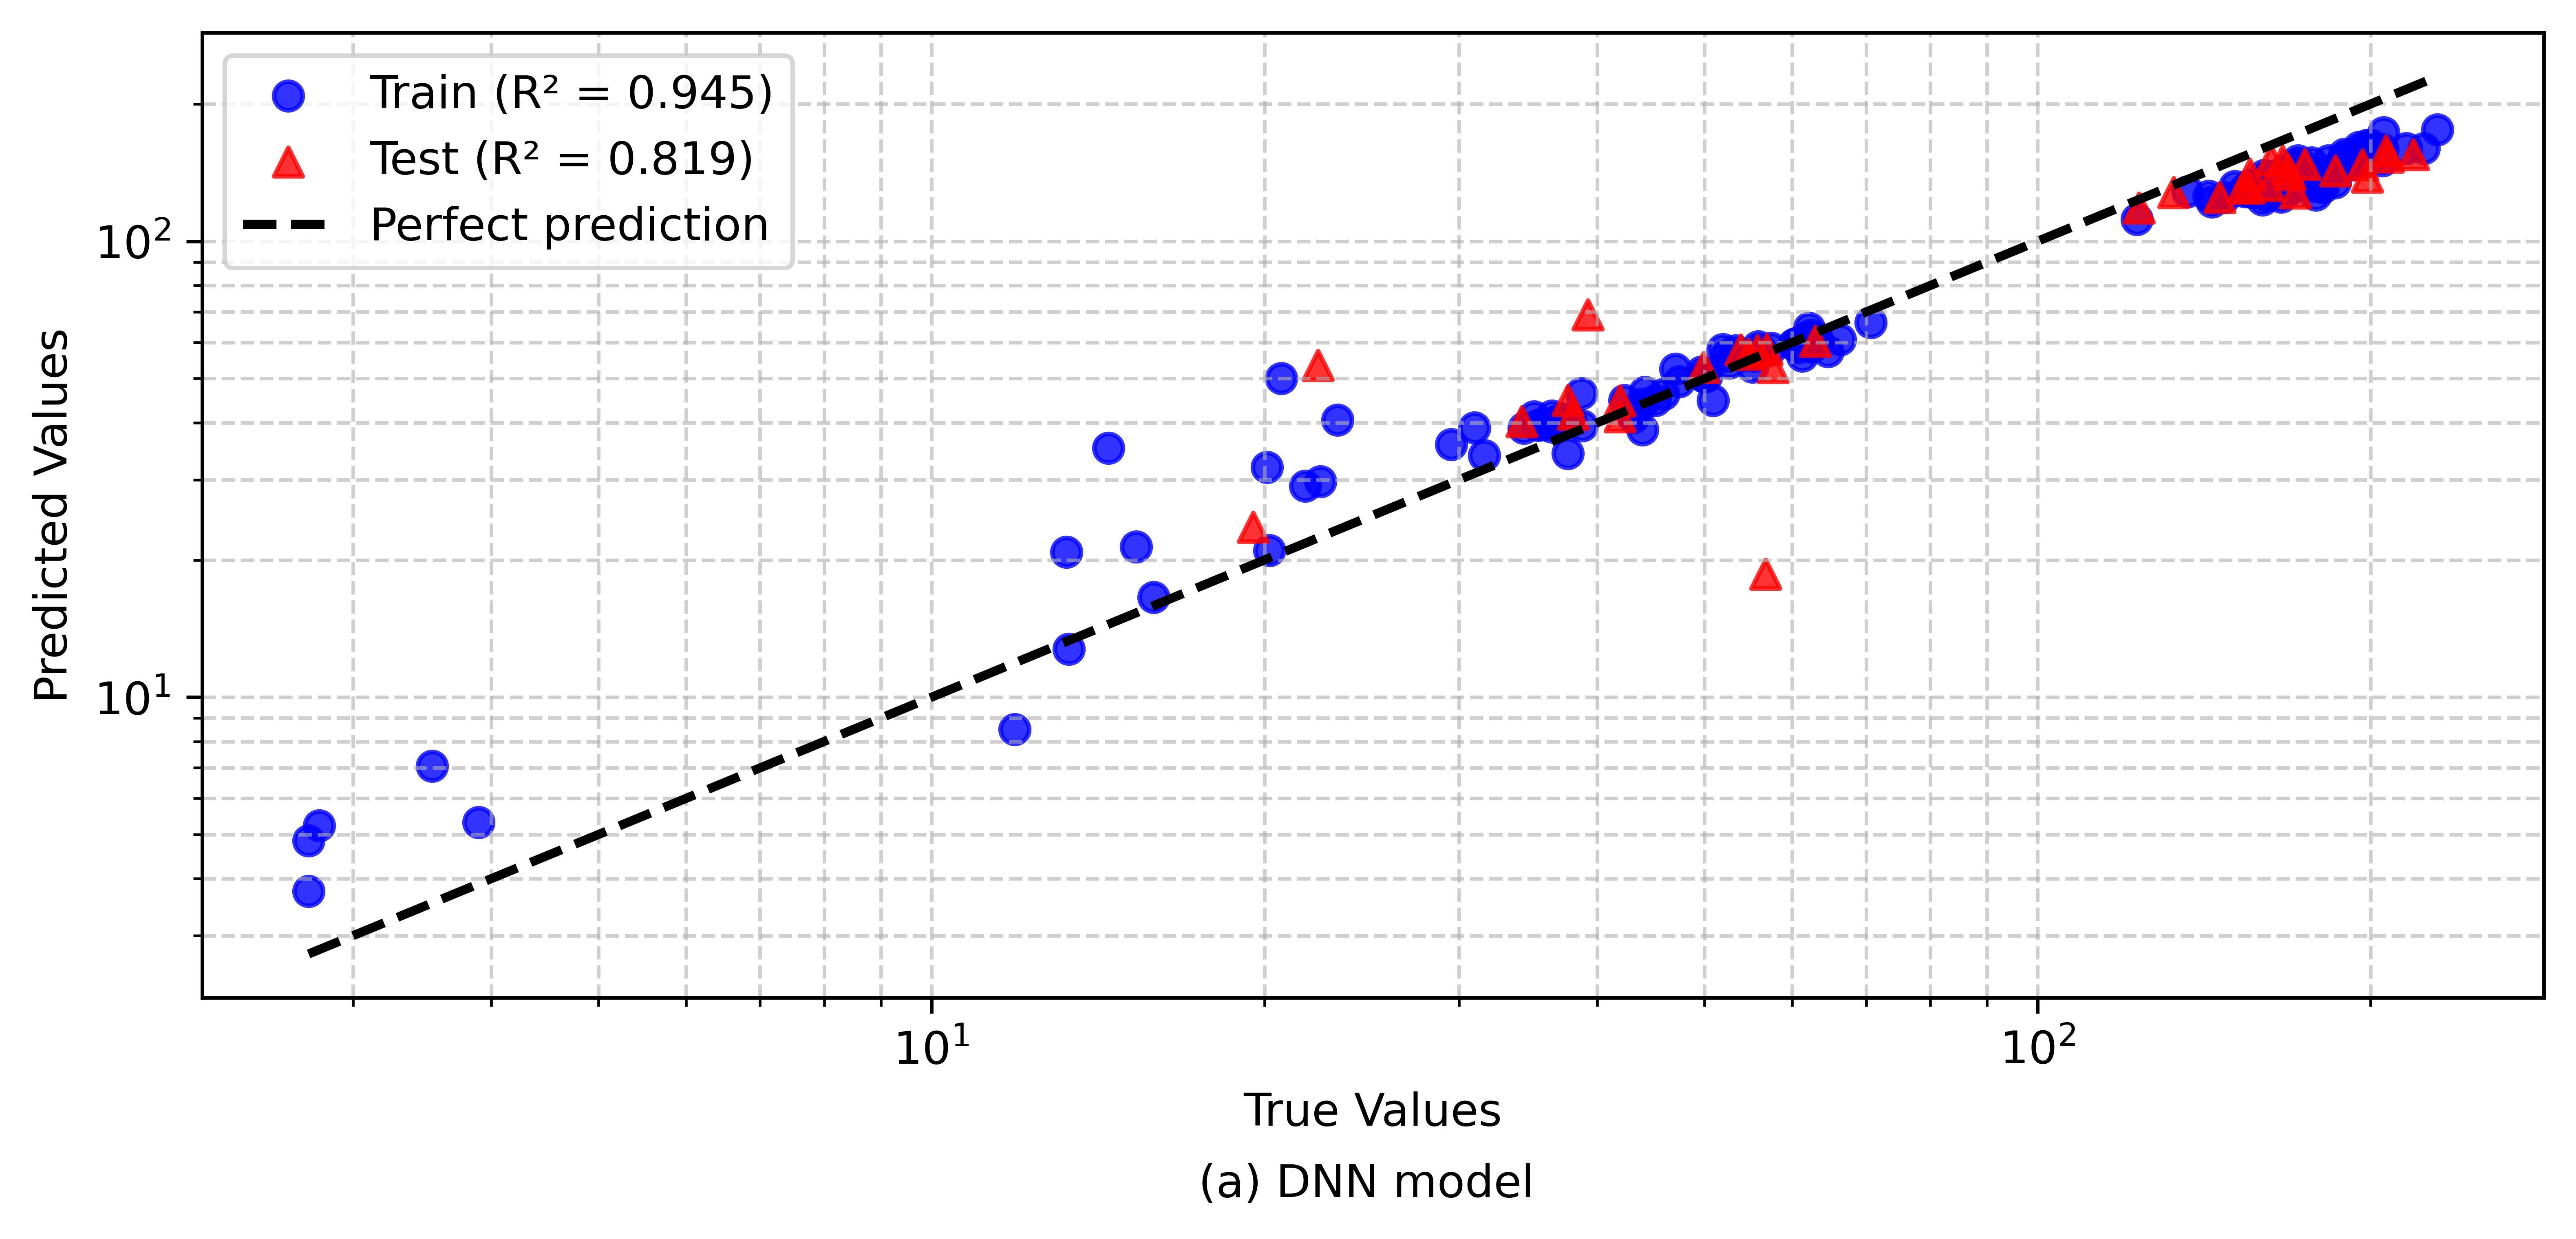

In [36]:
fig = plt.figure(figsize=(8, 4), dpi=800)

# Training data
plt.scatter(
    y_train_real, y_pred_train_real,
    color='blue',
    marker='o',          # Circle
    alpha=0.8,
    s=40,
    label=f'Train (R² = {r2_train:.3f})'
)

# Testing data
plt.scatter(
    y_test_real, y_pred_test_real,
    color='red',
    marker='^',          # traingle
    alpha=0.8,
    s=40,
    label=f'Test (R² = {r2_test:.3f})'
)

# Perfect prediction line
min_val = min(y_train_real.min(), y_test_real.min())
max_val = max(y_train_real.max(), y_test_real.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    lw=2,
    label='Perfect prediction'
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)

# Leave room at the bottom for the panel label
plt.tight_layout(rect=[0, 0.08, 1, 1])

# Bottom panel label
fig.text(
    0.53, 0.07,
    "(a) DNN model",
    ha="center",
    fontsize=10
)

filename_base = "DNN model performance"

plt.savefig(
    f"{filename_base}.tif",
    format="tiff",
    dpi=800,
    bbox_inches="tight"
)

plt.show()